# Plot pair-wise correlations

##### Project Description:

This notebook is trying to get pair-wise correlations between all human condensability scores in 1kb resolution.

##### Working Directory:

/Volumes/BackupHaLab/condense-seq/ipython_notebooks/[Ext. Fig.2j]E14_mouse.2026.ipynb

##### Start Date:

Jan 29, 2026

##### Editor:

Xin Lin

- This notebook is developed based on [Extended Data Fig.2j]human_1kb_score_corr.ipynb in the same folder.
- Here is the link to [Sangwoo's paper](https://www.nature.com/articles/s41586-025-08971-7)

In [31]:
# python modules
import sys, copy, random, re
from collections import defaultdict
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy
from scipy import stats

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Matplotlib:", mpl.__version__)
print("SciPy:", scipy.__version__)

# custom modules - Customized to BackupHaLab/
sys.path.append('/Volumes/BackupHaLab/condense-seq/postpro_scripts')
import graphics_edit as graphics
import load_file_edit as load_file
import Interval_dict_python3
import statis_edit as statis

Python: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
NumPy: 2.2.6
Matplotlib: 3.10.7
SciPy: 1.14.1


In [32]:
# matplotlib setting
%matplotlib inline
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["axes.facecolor"] = "white"
mpl.rcParams["savefig.facecolor"] = "white"

In [33]:
### parameters
cell_org = {'E14':'mouse'}

cell_chrnames = {'E14':['chr%s' % (i) for i in range(1, 20)] + ['chrX']}

agent_fullname = {'sp':'Spermine(4+)',
                  'spd':'Spermidine(3+)',
                  'CoH':'Cobalt Hexammine(3+)',
                  'PEG':'PEG 8000',
                  'HP1a':'HP1$\\alpha$',
                  'HP1bSUV':'HP1$\\beta$+tSUV',
                  'LKH':'Linker histone1',
                  'Ki67':'Ki67',
                  'FUS':'FUS',
                  'Mg':'Magnesium',
                  'Ca':'Calcium'}

agent_charge = {'sp':'4+',
                'spd':'3+',
                'CoH':'3+',
                'PEG':'',
                'Ca':'2+',
                'Mg':'2+',
                'HP1a':'',
                'HP1bSUV':'',
                'LKH':'',
                'Ki67':'',
                'FUS':''}

Here is when I realized that the input is "condensability fluctuation", instead of the real "condensability score". Therefore, I decided to use the output "*.bdg" files for IGV visualization as the input.

In [34]:
### load bedgraph files
working_dir = "/Volumes/BackupHaLab/"
bdg_dir = working_dir + "Oct2025_run/analysis_v2/bigwig/"

dinfo_key = {
    # 'E14_NCP_titr11_2rep_binsize25000_smoothed.bdg' : (2, 'E14', 'NCP', 'sp', 11),
    'E14_NCP_titr15_2rep_binsize25000_smoothed.bdg' : (2, 'E14', 'NCP', 'sp', 15),
    # 'Exp1-Samp11_S2_binsize25000_smoothed.bdg': (1, 'E14', 'Exp1', 'sp', 11),
    'Exp1-Samp15_S3_binsize25000_smoothed.bdg': (1, 'E14', 'Exp1', 'sp', 15),
    # 'Exp2-Samp11_S5_binsize25000_smoothed.bdg': (1, 'E14', 'Exp2', 'sp', 11),
    'Exp2-Samp15_S6_binsize25000_smoothed.bdg': (1, 'E14', 'Exp2', 'sp', 15),
    # 'Exp3-Samp11_S8_binsize25000_smoothed.bdg': (1, 'E14', 'Exp3', 'sp', 11),
    'Exp3-Samp15_S9_binsize25000_smoothed.bdg': (1, 'E14', 'Exp3', 'sp', 15),
    # 'Exp4-Samp11_S11_binsize25000_smoothed.bdg': (1, 'E14', 'Exp4', 'sp', 11),
    'Exp4-Samp15_S12_binsize25000_smoothed.bdg': (1, 'E14', 'Exp4', 'sp', 15),
    # 'Exp5-Samp11_S14_binsize25000_smoothed.bdg': (1, 'E14', 'Exp5', 'sp', 11),
    'Exp5-Samp15_S15_binsize25000_smoothed.bdg': (1, 'E14', 'Exp5', 'sp', 15),
    # 'Exp6-Samp11_S17_binsize25000_smoothed.bdg': (1, 'E14', 'Exp6', 'sp', 11),
    'Exp6-Samp15_S18_binsize25000_smoothed.bdg': (1, 'E14', 'Exp6', 'sp', 15),
}

def load_bedgraph(filename, working_dir):
    data = {}
    with open(f"{working_dir}/{filename}") as f:
        for line in f:
            if not line.strip():
                continue
            chrom, start, end, val = line.rstrip("\n").split("\t")
            key = (chrom, int(start), int(end))
            data[key] = float(val)
    return data

dkey_ID_score = {val : load_bedgraph(key, bdg_dir) for key, val in dinfo_key.items()}

dkey_list = list(dinfo_key.values())

In [35]:
### get common IDs
ID_list = set([])
for i in range(len(dkey_list)):
    dkey = dkey_list[i]
    if i == 0:
        keys = list(dkey_ID_score[dkey].keys())
        filtered_list = list(filter(lambda tup:tup[-1] > 2_500_000, keys))
        ID_list |= set(filtered_list)
        continue
    ID_list &= set(dkey_ID_score[dkey].keys())
ID_list = sorted(list(ID_list))
print(f"DEBUG: here is the ID_list: {ID_list[:5]} and total {len(ID_list)} IDs")

DEBUG: here is the ID_list: [('chr1', 3000000, 3025000), ('chr1', 3025000, 3050000), ('chr1', 3050000, 3075000), ('chr1', 3075000, 3100000), ('chr1', 3100000, 3125000)] and total 102519 IDs


In [36]:
### reorganize data and make labels
dkey_label = {}
dkey_data = {}
for dkey in dkey_list:
    rep, cell, sample, agent, tnum = dkey
    label = '%s\nTitr-%d' % (sample, tnum)
    print(f"the 'label' is {label}")
    dkey_label[dkey] = label
    data = [dkey_ID_score[dkey][ID] for ID in ID_list]
    print(f"the 'data' is {data[:5]} and the length of data is {len(data)}")
    dkey_data[dkey] = data
print(len(dkey_data))

the 'label' is NCP
Titr-15
the 'data' is [0.04405132091447925, 0.3421285702595809, 0.19511767072275255, 0.128186129598956, 0.23411882337594575] and the length of data is 102519
the 'label' is Exp1
Titr-15
the 'data' is [0.1626393933080545, 0.13680165679999995, 0.07233080399999996, 0.22812816720000004, -0.008851955200000016] and the length of data is 102519
the 'label' is Exp2
Titr-15
the 'data' is [0.41168552367288386, 0.3014516650693779, 0.040217051999999975, 0.28118862253943716, 0.1351164723530147] and the length of data is 102519
the 'label' is Exp3
Titr-15
the 'data' is [0.5137299873902079, 0.6775528204000001, 0.3143187742412384, 0.13575918913288051, 0.23529582560000004] and the length of data is 102519
the 'label' is Exp4
Titr-15
the 'data' is [0.28464327930330435, 0.4042455743989333, 0.4633997121488826, 0.23487653952811746, 0.4363094366431935] and the length of data is 102519
the 'label' is Exp5
Titr-15
the 'data' is [0.4361560326408147, 0.32469255671227903, 0.5088077810610538, 0

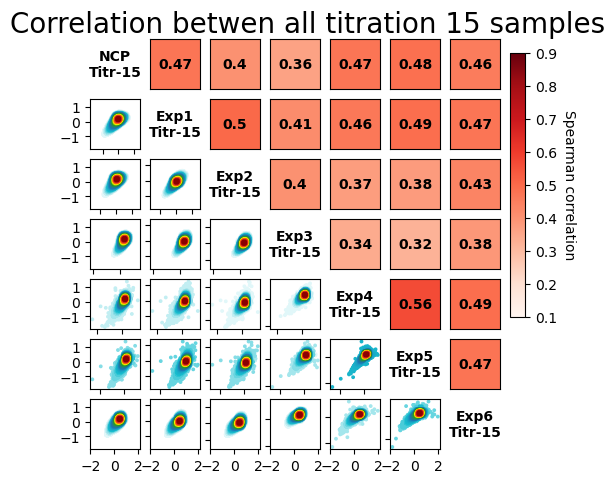

In [37]:
# plot correlation matrix between experiment [Extended Data Fig.2j]
graphics.plot_corr_matrix(dkey_data,
                          dkey_label,
                          ids = dkey_list,
                          scatter_style='density',
                          fig_scale=0.5,
                          cbar=True,
                          title = "Correlation betwen all titration 15 samples",
                          # save_path='./data/',
                          save=False,
                          note='E14_no_haps')